In [4]:
%pip install pandas numpy pyarrow

  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pyarrow-24.0.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached pyarrow-24.0.0-cp312-cp312-win_amd64.whl (27.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet('players_tidy.parquet')

# 2. Filter dataset: Retain only the 22 season (latest season) and exclude goalkeepers (GK)
# The attribute characteristics of goalkeepers differ greatly from those of other positions, and putting them into the same spatial clustering will lead to severe polarization.
df_ml = df[(df['season'] == 22) & (df['main_position'] != 'GK')].copy()

# 3. Define the 6 core ability features for clustering
features = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# 4. Extract the feature matrix X_raw and player metadata metadata for subsequent visualization
X_raw = df_ml[features]
metadata = df_ml[['sofifa_id', 'short_name', 'main_position', 'overall', 'value_eur']]

# 5. Print and check the data shape to ensure the filtering is correct
print(f"Number of non-goalkeeper players participating in clustering: {X_raw.shape[0]}")
print(f"Number of features used for clustering: {X_raw.shape[1]} ({', '.join(features)})")
display(X_raw.head())

Number of non-goalkeeper players participating in clustering: 17041
Number of features used for clustering: 6 (pace, shooting, passing, dribbling, defending, physic)


,pace,shooting,passing,dribbling,defending,physic
107590,85.0,92.0,91.0,95.0,34.0,65.0
107591,78.0,92.0,79.0,86.0,44.0,82.0
107592,87.0,94.0,80.0,88.0,34.0,75.0
107593,91.0,83.0,86.0,94.0,37.0,63.0
107594,76.0,86.0,93.0,88.0,64.0,78.0


In [3]:
%pip install scikit-learn matplotlib seaborn

  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.0 MB 2

The first two principal components of PCA explain the total variance of: 75.45%



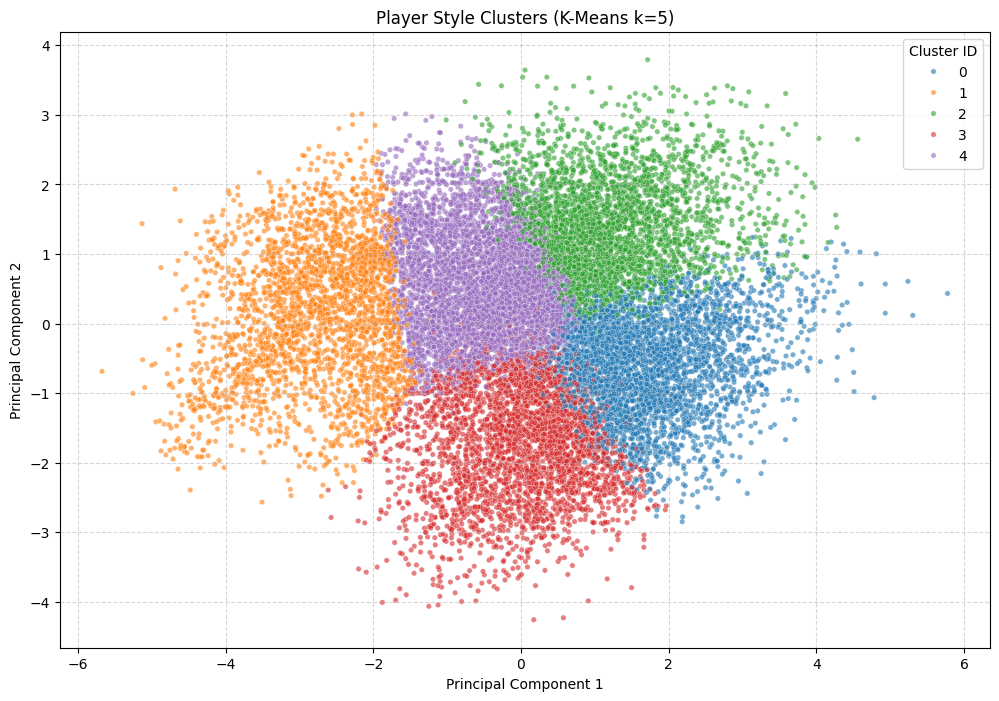

Average ability value of each cluster center (used to define player style):


,pace,shooting,passing,dribbling,defending,physic
Cluster ID,,,,,,
0,76.9,66.3,62.9,70.8,37.0,63.6
1,57.5,31.7,44.1,47.3,61.0,67.2
2,68.3,62.3,68.9,70.9,65.2,71.3
3,69.2,54.8,51.4,60.5,32.2,53.3
4,67.1,45.0,57.0,60.9,62.0,67.9


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Standardization (Mean = 0, Variance = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Build K-Means Model
# We fix random_state to ensure reproducible results, which is important for subsequent Web API deployment
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 3. PCA dimensionality reduction to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Evaluate the explanatory power of principal components
explained_variance = pca.explained_variance_ratio_.sum()
print(f"The first two principal components of PCA explain the total variance of: {explained_variance * 100:.2f}%\n")

# 4. Merge the clustering results and PCA coordinates back into the metadata DataFrame
metadata = metadata.copy()
metadata['cluster'] = cluster_labels
metadata['pca_x'] = X_pca[:, 0]
metadata['pca_y'] = X_pca[:, 1]

# 5. Draw cluster scatter plot after PCA dimensionality reduction
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_x', y='pca_y',
    hue='cluster',
    palette='tab10',
    data=metadata,
    s=15, alpha=0.6
)
plt.title(f'Player Style Clusters (K-Means k={k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 6. Calculate and print the centroids of each cluster in the original scale.
cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)
df_centers = pd.DataFrame(cluster_centers_original, columns=features)
df_centers.index.name = 'Cluster ID'

print("Average ability value of each cluster center (used to define player style):")
display(df_centers.round(1))

In [3]:
# 1. Define the style dictionary we just confirmed
cluster_names = {
    0: "Pacey Attackers",
    1: "Traditional Defenders",
    2: "All-Rounders",
    3: "Lightweight Attackers",
    4: "Ball-Playing Defenders"
}

# 2. Map the labels to the original data and add a new column named 'style_label'.
metadata['style_label'] = metadata['cluster'].map(cluster_names)

print("Player style mapping completed! Let's see the top representatives for each style:\n")
for i in range(5):
    top_players = metadata[metadata['cluster'] == i].nlargest(3, 'overall')['short_name'].tolist()
    print(f"🔹 {cluster_names[i]}: {', '.join(top_players)}")

Player style mapping completed! Let's see the top representatives for each style:

🔹 Pacey Attackers: L. Messi, Cristiano Ronaldo, Neymar Jr
🔹 Traditional Defenders: W. Orban, Unai Núñez, Laguardia
🔹 All-Rounders: R. Lewandowski, K. De Bruyne, H. Kane
🔹 Lightweight Attackers: R. Inglese, Dagoberto Esteiro, R. Santa Cruz
🔹 Ball-Playing Defenders: G. Chiellini, K. Koulibaly, M. Škriniar
